In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 1200,
})

import yaml
import numpy as np

import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

from irc.manager import IRCManager

from auditoryforage.utils import plot_AF_episode

/home/lokesh/anaconda3/envs/IRC/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Train one agent for a single environment

In [2]:
defaults = {
    'agent.env._target_': 'auditoryforage.AF_env.AuditoryForaging',
    'agent.model._target_': 'irc.model.FuncBeliefModel',
}
manager = IRCManager(defaults=defaults)

## Train an agent
We train a rational agent for the assume environment parameter [$lick\_cost, food\_reward, attention\_cost\_coeff, attention\_cost\_temp, penalty\_cost, iti\_cost$].

Checkpoint (epoch 369) loaded.
Fetching the most trained agent so far (epoch 369).
Agent (seed 0) was trained for 369 epochs, RL optimality 96.83%.


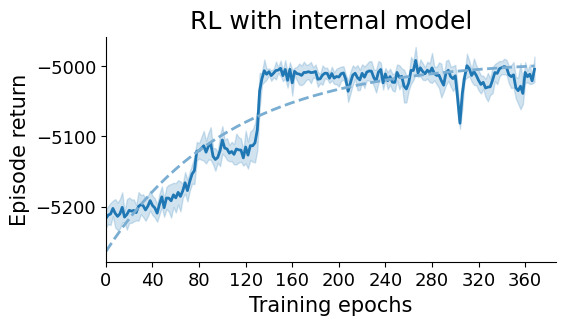

In [3]:
env_param = [-3.0, 200.0, .08, .25, -5000, 0]
num_epochs = 369

agent = manager.train_agent(env_param, num_epochs=num_epochs)
agent, fig = manager.inspect_agent(env_param, figsize=(5, 2.5))

## Run the agent in an environment
We create another environment which has the same observation space and action space as the assumed one, albeit with a different set of environment parameters.

problem somwhere here
[[3]
 [3]
 [3]
 ...
 [0]
 [0]
 [2]]
(array([2015]), array([0]))
problem somwhere here
[[3]
 [3]
 [3]
 ...
 [1]
 [1]
 [2]]
(array([2015]), array([0]))


{'agent': {'lick_cost': -3.0,
  'food_reward': 200.0,
  'attention_cost_coeff': 0.08,
  'attention_cost_temp': 0.25,
  'penalty_cost': -5000,
  'iti_cost': 0,
  'no_attention_modes': 6},
 'experiment': {'prob_01': 0.004,
  'no_signal_nodes': 150,
  'no_penalty_nodes': 1,
  'no_ITI_nodes': 150}}

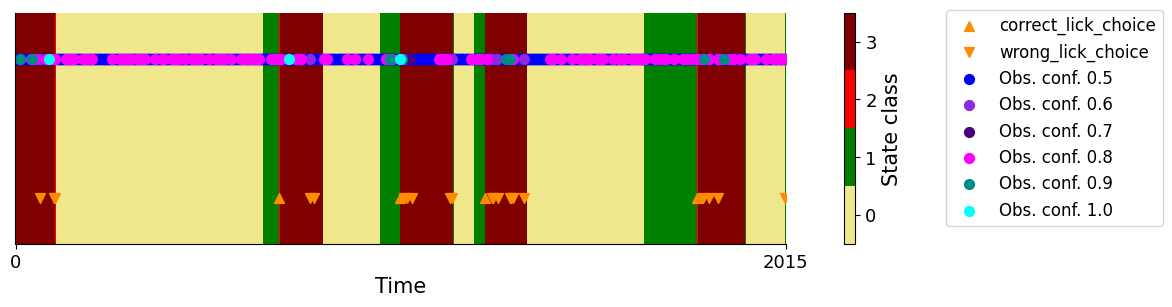

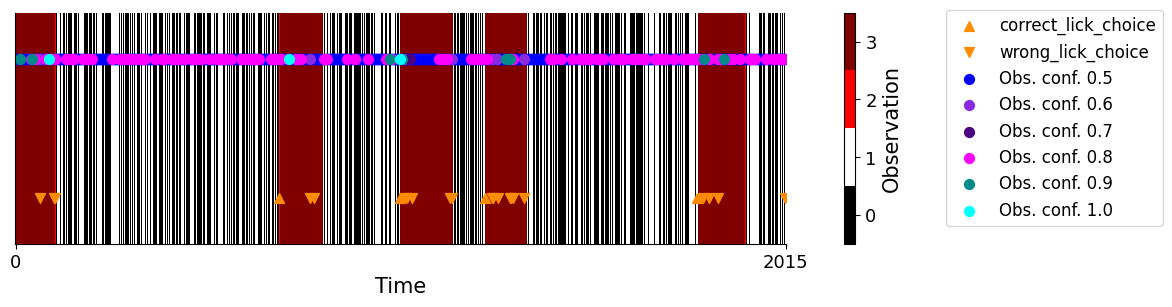

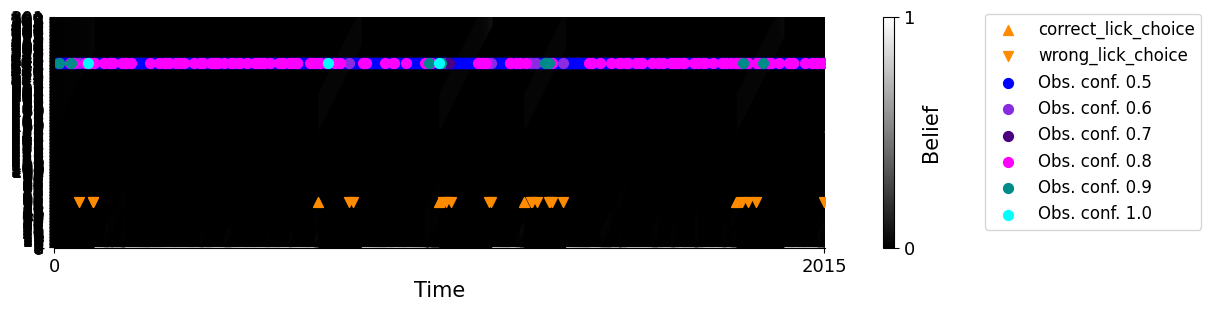

In [4]:
from auditoryforage.AF_env import AuditoryForaging

# Change below line if you want to try the trained model on a different set of environemnt.
# env_param = [-3.0, 8.0, 13, 8, -8, -4]

env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5]}})
episode = agent.run_one_episode(env=env, num_steps=10000, q_states = [[i] for i in range(env.no_nodes)])
fig = plot_AF_episode(episode, env, agent, nodes_from_zero = 40, time_steps_before_lick = 20)

env.spec



# Particle filter

## Running particle filter once

In [ ]:
from auditoryforage.utils import particle_filter
end_index = 200
no_particles = 500

state_list = [list_of_state[0] for list_of_state in episode['states']]
lick_actions = [env.dict_action_possible[action][0] for action in episode['actions']]

# state_list = state_list[:end_index]
# lick_actions = lick_actions[:end_index]

state_list = state_list
lick_actions = lick_actions

particle_filter_output = particle_filter(agent = agent, env = env, lick_actions = lick_actions, state_list = state_list, no_particles = no_particles, sampling_freq = 1)

## Saving particle filter output

In [8]:
import pickle 

reference_episode = episode
particle_filter_compare_data = {'reference_episode': episode, "particle_filter_output": particle_filter_output}
file_name = "PF_IO_episodes.pkl"

open_file = open(file_name, "wb")
pickle.dump(particle_filter_compare_data, open_file)
open_file.close()

open_file = open(file_name, "rb")
particle_filter_compare_data_loaded = pickle.load(open_file)
open_file.close()

## Run and save particle filters' outputs in parallel

In [ ]:
from auditoryforage.utils import particle_filter
end_index = 200
no_particles = 500
state_list = [list_of_state[0] for list_of_state in episode['states']]
lick_actions = [env.dict_action_possible[action][0] for action in episode['actions']]

import pickle 
reference_episode = episode

import multiprocessing
number_of_runs = 5
file_names = [f'PF_IO_episodes_run_{ind}' for ind in range(number_of_runs)]

def run_and_save_particle_filter(file_name):
    particle_filter_output = particle_filter(agent = agent, env = env, lick_actions = lick_actions, state_list = state_list, no_particles = no_particles, sampling_freq = 1)
    particle_filter_compare_data = {'reference_episode': episode, "particle_filter_output": particle_filter_output}
    open_file = open(file_name, "wb")
    pickle.dump(particle_filter_compare_data, open_file)
    open_file.close()
    print(f'Saved file {file_name}', flush=True)

with multiprocessing.Pool() as pool:
    pool.map(run_and_save_particle_filter, file_names)

## Loading saved particle filter output

In [5]:
import pickle 

file_name = "PF_IO_episodes.pkl"

open_file = open(file_name, "rb")
particle_filter_compare_data = pickle.load(open_file)
open_file.close()

## Analyzing particle filter output
### Considering one of the generated episodes for analysis. Can pick which one, for now using the first one (one with highest absolute likelihood).

In [42]:
chosen_generated_episode_ind = 0
generated_episode = particle_filter_compare_data['particle_filter_output']['generated_episodes'][chosen_generated_episode_ind]

### Computing the error rate, that is the average difference between generated attentions and true attentions, computed per time step.

In [46]:
# computing error rate
generated_attention = np.array([env.dict_action_possible[int(action)][1] for action in generated_episode['actions']])
actual_attention = np.array([env.dict_action_possible[int(action)][1] for action in episode['actions']])
error_rate = np.sum(np.abs(generated_attention-actual_attention))/len(generated_attention)
print(f'Avgerage attention error rate between generated episode index-{chosen_generated_episode_ind} and true episode is {error_rate} per time step.')

Avgerage attention error rate between generated episode index-0 and true episode is 0.24714640198511167 per time step.


### Plotting generated episode.

problem somwhere here
[[3]
 [3]
 [3]
 ...
 [0]
 [0]
 [2]]
(array([2015]), array([0]))
problem somwhere here
[[3]
 [3]
 [3]
 ...
 [1]
 [1]
 [1]]
(array([], dtype=int64), array([], dtype=int64))


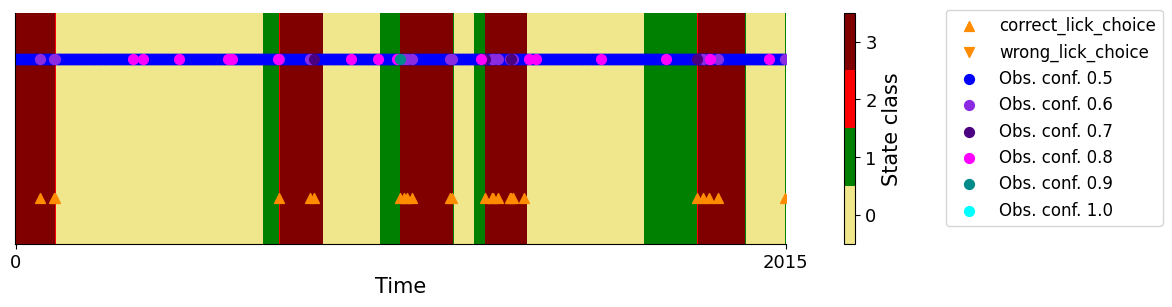

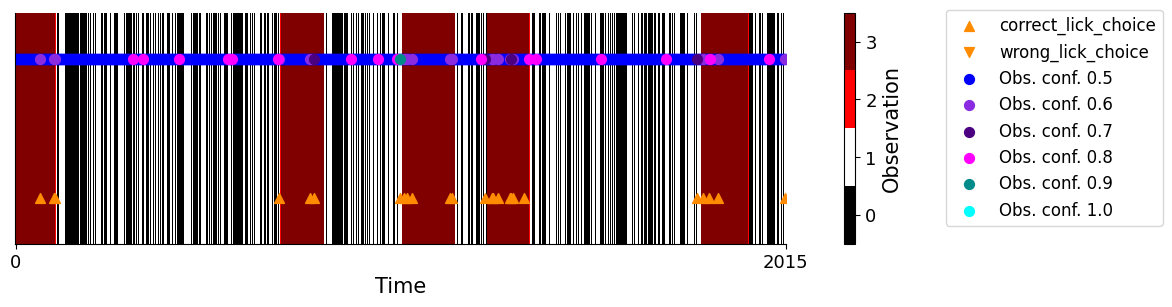

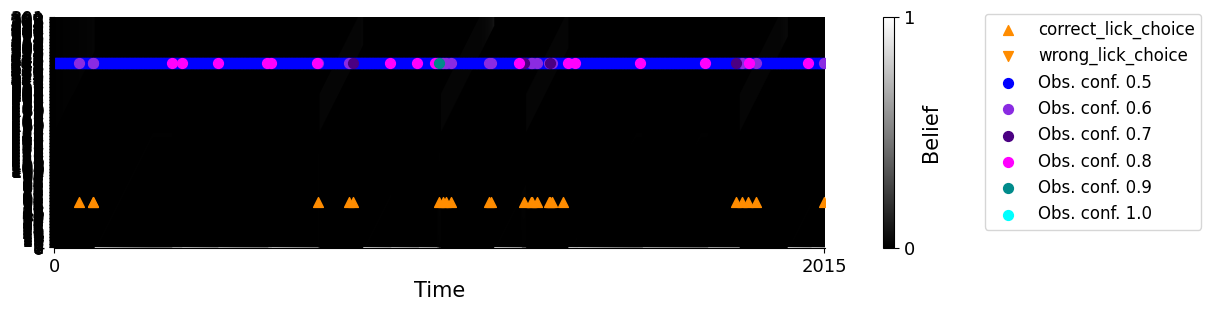

In [47]:
generated_episode['rewards'] = np.zeros(len(generated_episode['actions']))
fig = plot_AF_episode(generated_episode, env, agent, nodes_from_zero = 40, time_steps_before_lick = 20)

### Plotting absolute likelihoods of all particles.

In [48]:
particles_likelihoods = particle_filter_compare_data['particle_filter_output']['particles_likelihoods']
if np.sum(particles_likelihoods) == 0:
    print('Absolute particle likelihoods for all particles are close to 0.')
else:
    plt.stem(particle_filter_compare_data['particle_filter_output']['particles_likelihoods'])
    plt.show()

Absolute particle likelihoods for all particles are close to 0.


### Checking if there are at least two particles with different trajectories.

In [38]:
no_particles = 500

need_no_particles = False
did_it_converge = False
try: no_particles
except NameError: need_no_particles = True
if not need_no_particles:
    ind = 0
    diff_in_actions = 0
    while diff_in_actions == 0:
        ind += 1
        if ind > no_particles - 1:
            did_it_converge = True
            print('All particles converged to the same trajectory.')
            break
        a = particle_filter_compare_data['particle_filter_output']['generated_episodes'][0]['actions']
        b = particle_filter_compare_data['particle_filter_output']['generated_episodes'][ind]['actions']
        diff_in_actions = np.sum(np.abs(a-b))/len(a)
    if not did_it_converge:
        print('Found at least two particles with different trajectories, namely particle {ind} and particle 0.')
        print(f'Rate of difference in actions between them is {diff_in_actions} per time step.')
else:
    print('Provide number of particles before running this code!')

All particles converged to the same trajectory.


No. of non-zero attention instances in reference episode is 165.
No. of non-zero attention instances in generated episode index-0 is 41.


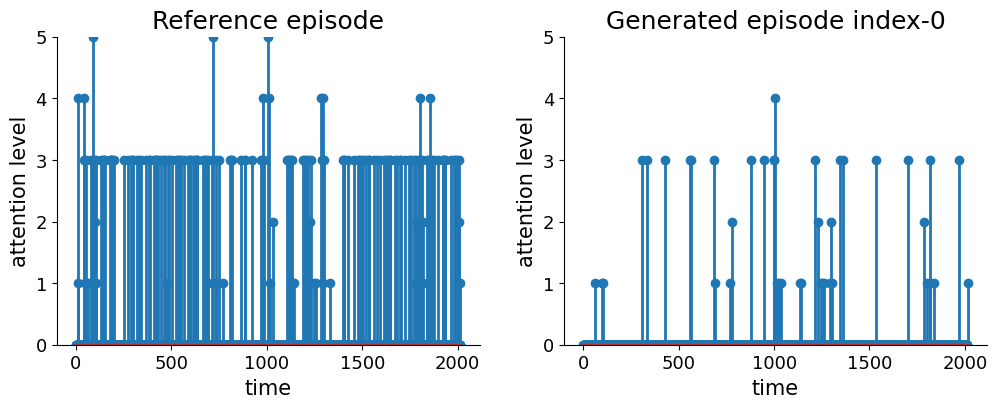

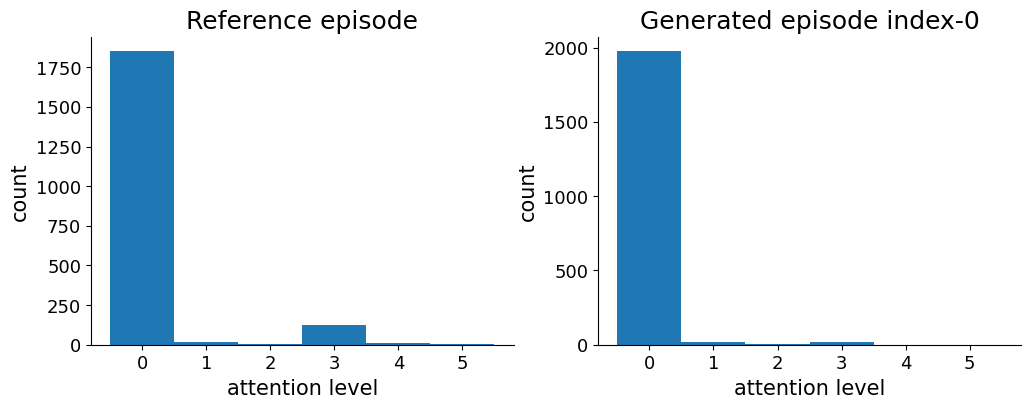

In [79]:
print(f'No. of non-zero attention instances in reference episode is {np.sum(actual_attention > 0)}.')
print(f'No. of non-zero attention instances in generated episode index-{chosen_generated_episode_ind} is {np.sum(generated_attention > 0)}.')

# Attention Vs Time
plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.stem(actual_attention)
plt.xlabel('time')
plt.ylabel('attention level')
plt.ylim([0,env.no_attention_modes-1])
plt.title(f'Reference episode')
plt.subplot(1, 2, 2)
plt.stem(generated_attention)
plt.xlabel('time')
plt.ylabel('attention level')
plt.ylim([0,env.no_attention_modes-1])
plt.title(f'Generated episode index-{chosen_generated_episode_ind}')

# Attention histograms
plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.hist(actual_attention, bins = [attention-.5 for attention in range(env.no_attention_modes+1)])
plt.xlabel('attention level')
# plt.xlim([0,5])
plt.ylabel('count')
plt.title(f'Reference episode')
plt.subplot(1, 2, 2)
plt.hist(generated_attention, bins = [attention-.5 for attention in range(env.no_attention_modes+1)])
plt.xlabel('attention level')
# plt.xlim([0,5])
plt.ylabel('count')
plt.title(f'Generated episode index-{chosen_generated_episode_ind}')
plt.show()